In [12]:
# ============================================================
# ANÁLISE EXPLORATÓRIA — Sistema Comercial de Saneamento
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Configurações visuais ---
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COR_PRINCIPAL  = '#1B4F8A'
COR_ALERTA     = '#E84855'
COR_OK         = '#2ECC71'
COR_NEUTRO     = '#95A5A6'

# --- Carregar bases ---
caminho = "/home/matheus/Documents/CASE SANOVA/micromedicao/data/processed/"

df       = pd.read_excel(caminho + "base_completa_tratada.xlsx")
df_at    = pd.read_excel(caminho + "base_ativas_tratada.xlsx")
df_nat   = pd.read_excel(caminho + "base_nao_ativas_tratada.xlsx")

print("✅ Bases carregadas:")
print(f"   Completa:   {df.shape}")
print(f"   Ativas:     {df_at.shape}")
print(f"   Não ativas: {df_nat.shape}")

✅ Bases carregadas:
   Completa:   (1912, 161)
   Ativas:     (1815, 161)
   Não ativas: (97, 161)


In [13]:
flags = [col for col in df_at.columns if 'FLAG' in col]
print(f"Total de flags em df_at: {len(flags)}")
print(flags)

Total de flags em df_at: 14
['FLAG_SIT_AGUA_NULA', 'FLAG_SIT_ESGOTO_NULA', 'FLAG_SEM_CATEGORIA', 'FLAG_SEM_HIDROMETRO', 'FLAG_SEM_ECONOMIA', 'FLAG_INCONSISTENCIA_SITUACAO', 'FLAG_SERVICO_NEGATIVO', 'FLAG_FATURAMENTO_ZERADO', 'FLAG_SERVICO_EXTREMO', 'FLAG_TODOS_MESES_ZERO', 'FLAG_SUBFATURAMENTO', 'FLAG_HIDROMETRO_ANTIGO', 'FLAG_CONSUMO_ZERO_RECORRENTE', 'FLAG_ALTA_VARIABILIDADE']


In [14]:
# ============================================================
# DEFINIÇÃO DAS COLUNAS HISTÓRICAS — 12 MESES (_01 a _12)
# Premissa: mês base = período atual de referência (sem sufixo)
# ============================================================

volume_real_cols  = [f'VOLUME_REAL_{str(i).zfill(2)}'    for i in range(1,13)]
volume_fat_cols   = [f'VOLUME_FATURADO_{str(i).zfill(2)}' for i in range(1,13)]
valor_total_cols  = [f'VALOR_TOTAL_{str(i).zfill(2)}'    for i in range(1,13)]
valor_agua_cols   = [f'VALOR_AGUA_{str(i).zfill(2)}'     for i in range(1,13)]
valor_esgoto_cols = [f'VALOR_ESGOTO_{str(i).zfill(2)}'   for i in range(1,13)]

meses_label = ['Jan','Fev','Mar','Abr','Mai','Jun',
               'Jul','Ago','Set','Out','Nov','Dez']

print("✅ Colunas históricas definidas — 12 meses (_01 a _12)")
print(f"   Volume real:   {len(volume_real_cols)} colunas")
print(f"   Valor total:   {len(valor_total_cols)} colunas")
print(f"   Meses label:   {meses_label}")

✅ Colunas históricas definidas — 12 meses (_01 a _12)
   Volume real:   12 colunas
   Valor total:   12 colunas
   Meses label:   ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']


✅ Pasta output criada/confirmada: /home/matheus/Documents/CASE SANOVA/micromedicao/data/output/


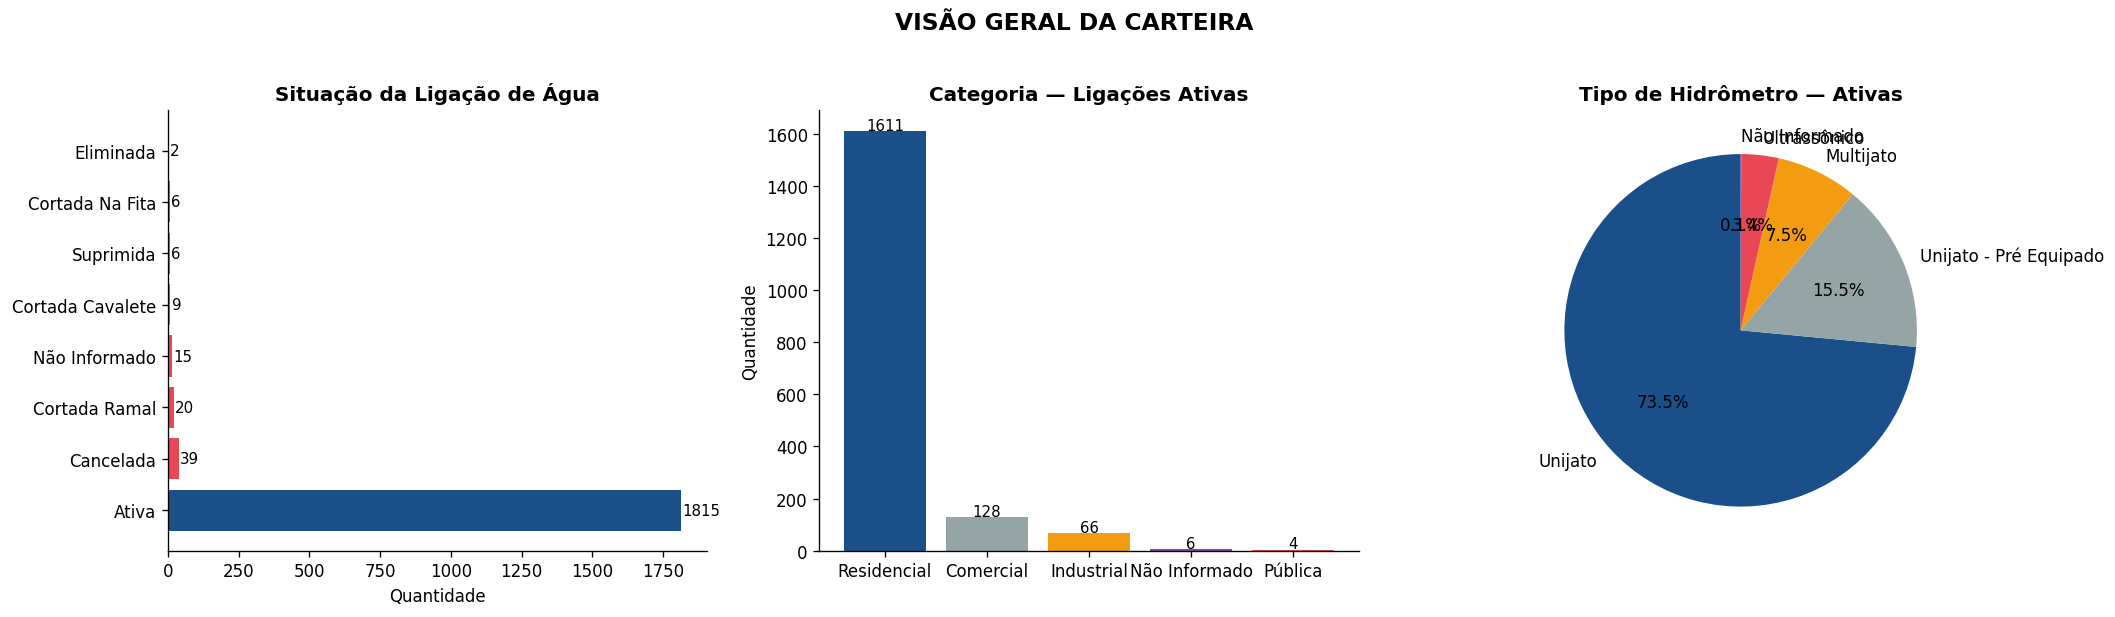

✅ Gráfico 01 salvo


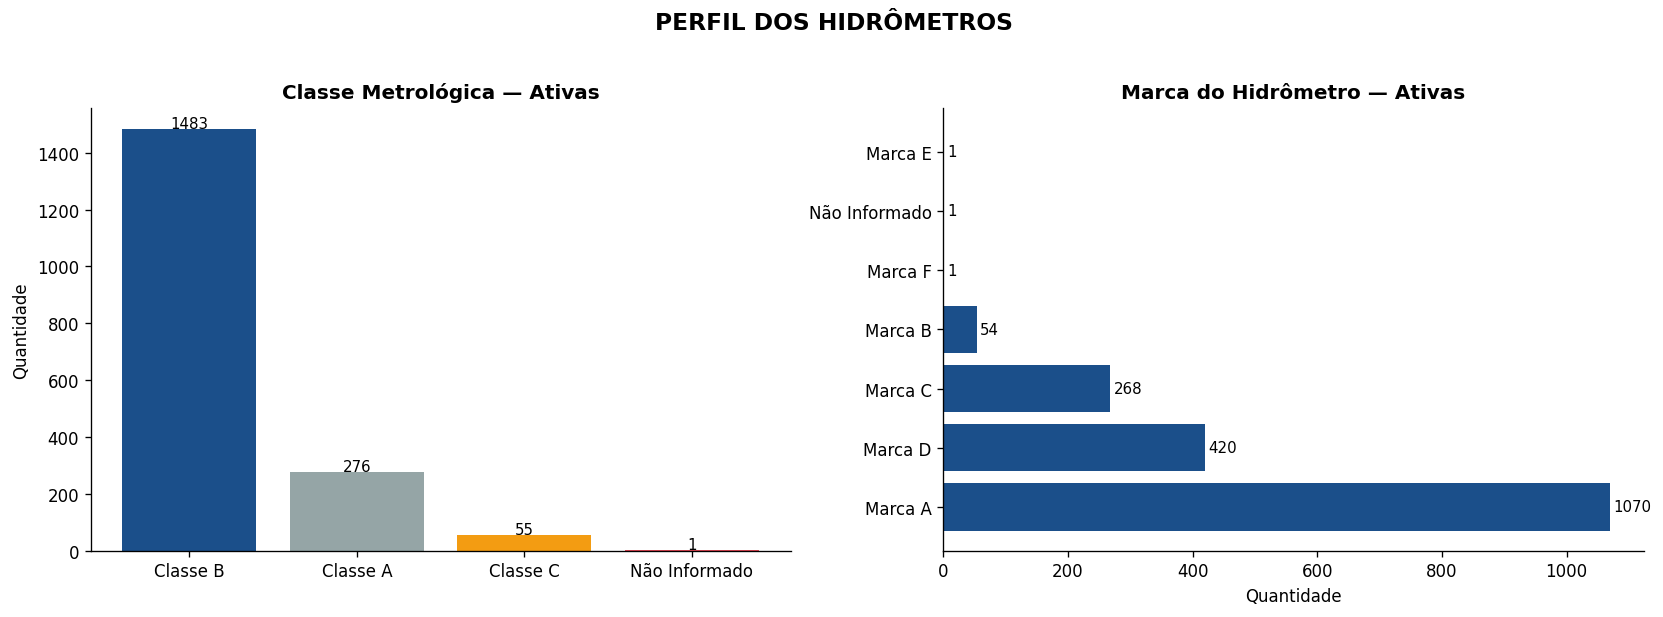

✅ Gráfico 02 salvo

=== RESUMO DA CARTEIRA ===

Total de ligações na base:            1912
  └─ Ativas:                          1815 (94.9%)
  └─ Não ativas:                        97 (5.1%)

Economias ativas por categoria:
  Residencial:                        4469
  Comercial:                           690
  Industrial:                           67
  Pública:                               4
  Total de economias:                 5230

Faturamento total histórico (base): R$   11,308,892.53
Faturamento médio por ligação/mês:  R$          531.78


In [15]:
# ============================================================
# BLOCO 1 — VISÃO GERAL DA CARTEIRA
# ============================================================
import os

# Criar pasta output se não existir
output_path = caminho.replace('processed/', 'output/')
os.makedirs(output_path, exist_ok=True)
print(f"✅ Pasta output criada/confirmada: {output_path}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1.1 Situação água (substitui NaN por 'Não Informado') ---
sit_agua = df['SIT._LIG_AGUA'].fillna('Não Informado').value_counts()
cores_sit = [COR_PRINCIPAL if v == 'Ativa' else COR_ALERTA for v in sit_agua.index]
axes[0].barh(sit_agua.index, sit_agua.values, color=cores_sit)
axes[0].set_title('Situação da Ligação de Água', fontweight='bold')
axes[0].set_xlabel('Quantidade')
for i, v in enumerate(sit_agua.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# --- 1.2 Categoria principal ---
cat = df_at['CATEGORIA_PRINCIPAL'].fillna('Não Informado').value_counts()
cores_cat = [COR_PRINCIPAL, COR_NEUTRO, '#F39C12', '#8E44AD', COR_ALERTA]
axes[1].bar(cat.index, cat.values, color=cores_cat[:len(cat)])
axes[1].set_title('Categoria — Ligações Ativas', fontweight='bold')
axes[1].set_ylabel('Quantidade')
for i, v in enumerate(cat.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9)

# --- 1.3 Tipo de hidrômetro ---
tipo_hid = df_at['TIPO_HIDROMETRO'].fillna('Não Informado').value_counts()
axes[2].pie(
    tipo_hid.values,
    labels=tipo_hid.index,
    autopct='%1.1f%%',
    colors=[COR_PRINCIPAL, COR_NEUTRO, '#F39C12', COR_ALERTA, '#8E44AD'],
    startangle=90
)
axes[2].set_title('Tipo de Hidrômetro — Ativas', fontweight='bold')

plt.suptitle('VISÃO GERAL DA CARTEIRA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(caminho.replace('processed/', 'output/') + '01_visao_geral_carteira.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Gráfico 01 salvo")

# --- 1.4 Classe metrológica e marca ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classe = df_at['CLASSE_METROLOGICA'].fillna('Não Informado').value_counts()
axes[0].bar(classe.index, classe.values,
            color=[COR_PRINCIPAL, COR_NEUTRO, '#F39C12', COR_ALERTA])
axes[0].set_title('Classe Metrológica — Ativas', fontweight='bold')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(classe.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

marca = df_at['MARCA_HIDROMETRO'].fillna('Não Informado').value_counts()
axes[1].barh(marca.index, marca.values, color=COR_PRINCIPAL)
axes[1].set_title('Marca do Hidrômetro — Ativas', fontweight='bold')
axes[1].set_xlabel('Quantidade')
for i, v in enumerate(marca.values):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=9)

plt.suptitle('PERFIL DOS HIDRÔMETROS', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(caminho.replace('processed/', 'output/') + '02_perfil_hidrometros.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Gráfico 02 salvo")

# --- 1.5 Resumo numérico ---
total_economias = df_at[['NUMERO_ECONOMIAS_RES','NUMERO_ECONOMIAS_COM',
                          'NUMERO_ECONOMIAS_IND','NUMERO_ECONOMIAS_PUB']].sum()

print("\n=== RESUMO DA CARTEIRA ===\n")
print(f"Total de ligações na base:          {len(df):>6}")
print(f"  └─ Ativas:                        {len(df_at):>6} ({len(df_at)/len(df)*100:.1f}%)")
print(f"  └─ Não ativas:                    {len(df_nat):>6} ({len(df_nat)/len(df)*100:.1f}%)")
print(f"\nEconomias ativas por categoria:")
print(f"  Residencial:                      {int(total_economias['NUMERO_ECONOMIAS_RES']):>6}")
print(f"  Comercial:                        {int(total_economias['NUMERO_ECONOMIAS_COM']):>6}")
print(f"  Industrial:                       {int(total_economias['NUMERO_ECONOMIAS_IND']):>6}")
print(f"  Pública:                          {int(total_economias['NUMERO_ECONOMIAS_PUB']):>6}")
print(f"  Total de economias:               {int(total_economias.sum()):>6}")
print(f"\nFaturamento total histórico (base): R$ {df_at['TOTAL_FATURADO_HISTORICO'].sum():>15,.2f}")
print(f"Faturamento médio por ligação/mês:  R$ {df_at['MEDIA_FATURADO_HISTORICO'].mean():>15,.2f}")

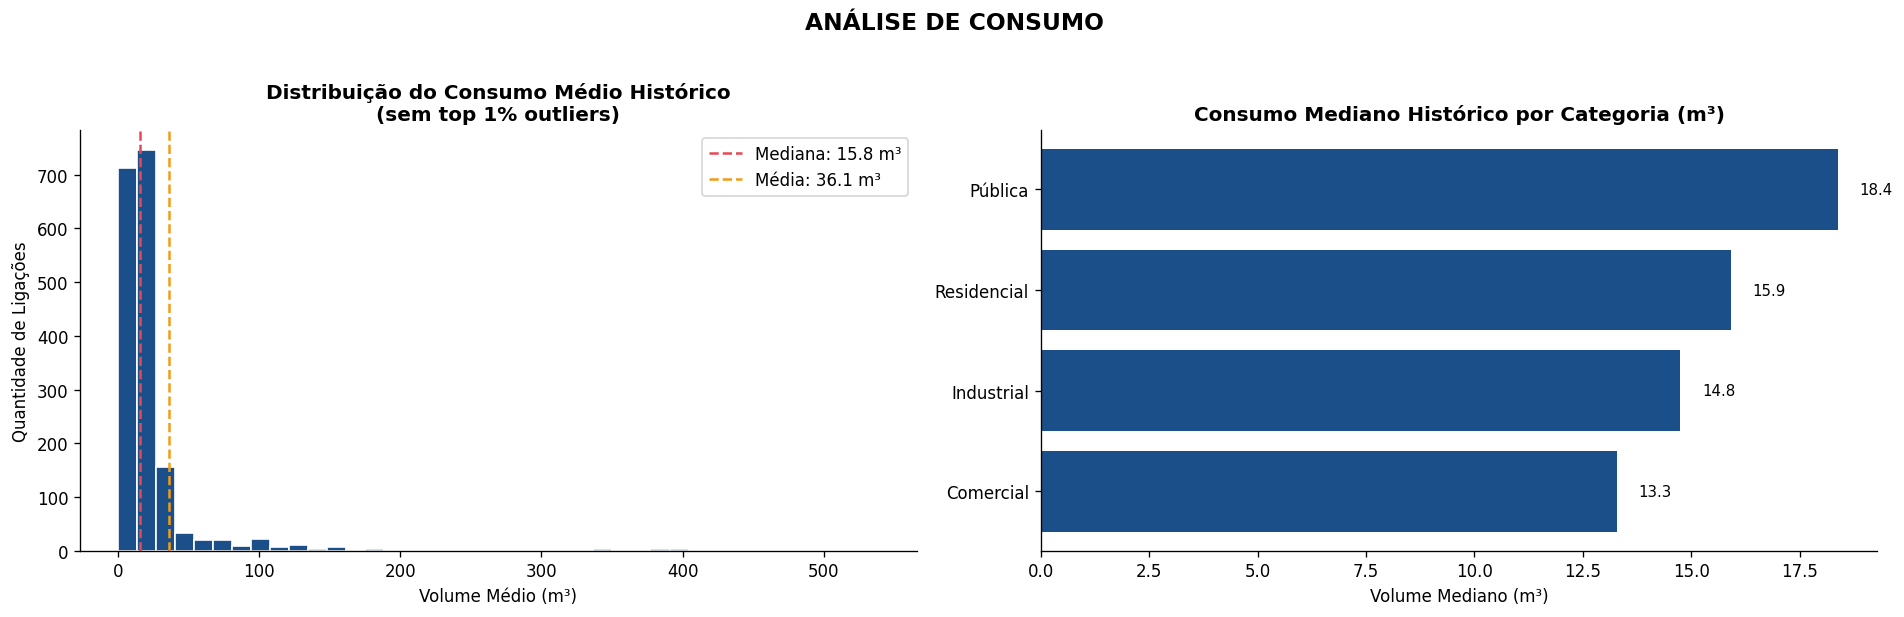

✅ Gráfico 03 salvo


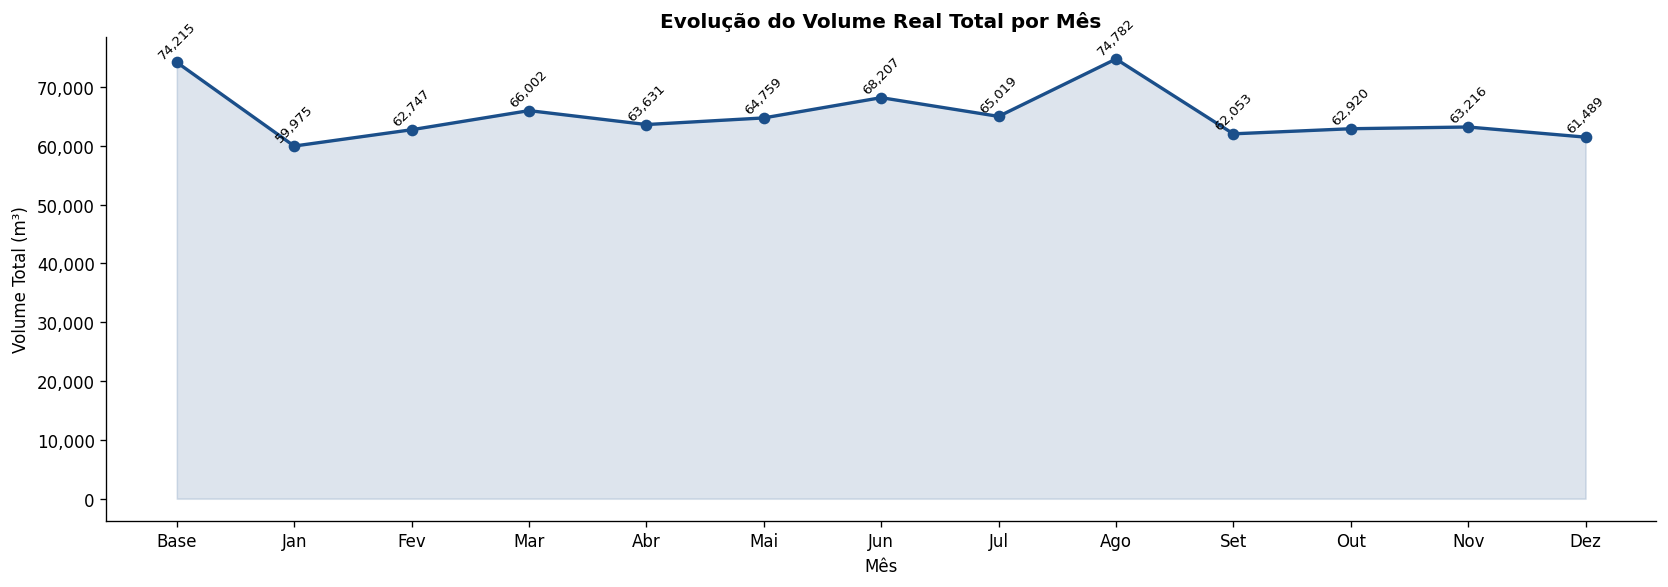

✅ Gráfico 04 salvo


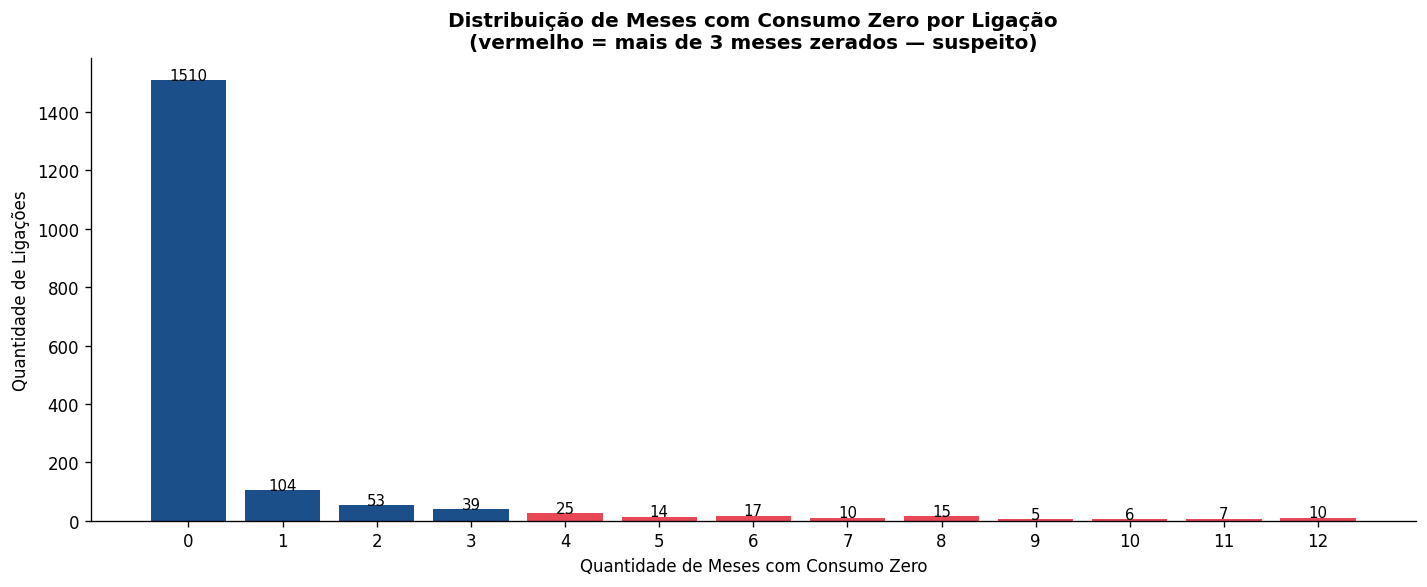

✅ Gráfico 05 salvo

=== RESUMO DE CONSUMO ===

Consumo médio histórico (mediana):      15.8 m³/mês
Consumo médio histórico (média):        36.1 m³/mês
Ligações com consumo zero > 3 meses:    109 ligações
Ligações com todos os meses zerados:    10 ligações
Volume total histórico da base:         774,800 m³

Consumo mediano por categoria:
  Comercial       13.3 m³/mês
  Industrial      14.8 m³/mês
  Residencial     15.9 m³/mês
  Pública         18.4 m³/mês


In [16]:
# ============================================================
# BLOCO 2 — ANÁLISE DE CONSUMO
# ============================================================

volume_real_cols = ['VOLUME_REAL'] + [f'VOLUME_REAL_{str(i).zfill(2)}' for i in range(1,13)]
valor_total_cols = ['VALOR_TOTAL'] + [f'VALOR_TOTAL_{str(i).zfill(2)}' for i in range(1,13)]
meses_label = ['Base','Jan','Fev','Mar','Abr','Mai','Jun',
               'Jul','Ago','Set','Out','Nov','Dez']

# --- 2.1 Distribuição do consumo médio histórico (sem outliers extremos) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

consumo_plot = df_at['MEDIA_CONSUMO_HISTORICO']
consumo_plot_sem_outlier = consumo_plot[consumo_plot <= consumo_plot.quantile(0.99)]

axes[0].hist(consumo_plot_sem_outlier, bins=40, color=COR_PRINCIPAL, edgecolor='white')
axes[0].axvline(consumo_plot.median(), color=COR_ALERTA, linestyle='--',
                linewidth=1.5, label=f'Mediana: {consumo_plot.median():.1f} m³')
axes[0].axvline(consumo_plot.mean(), color='#F39C12', linestyle='--',
                linewidth=1.5, label=f'Média: {consumo_plot.mean():.1f} m³')
axes[0].set_title('Distribuição do Consumo Médio Histórico\n(sem top 1% outliers)', fontweight='bold')
axes[0].set_xlabel('Volume Médio (m³)')
axes[0].set_ylabel('Quantidade de Ligações')
axes[0].legend()

# Consumo médio por categoria
consumo_cat = df_at.groupby('CATEGORIA_PRINCIPAL')['MEDIA_CONSUMO_HISTORICO'].median().sort_values()
cores_cat = [COR_PRINCIPAL] * len(consumo_cat)
axes[1].barh(consumo_cat.index, consumo_cat.values, color=cores_cat)
axes[1].set_title('Consumo Mediano Histórico por Categoria (m³)', fontweight='bold')
axes[1].set_xlabel('Volume Mediano (m³)')
for i, v in enumerate(consumo_cat.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=9)

plt.suptitle('ANÁLISE DE CONSUMO', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(output_path + '03_distribuicao_consumo.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Gráfico 03 salvo")

# --- 2.2 Evolução do consumo total ao longo dos meses ---
fig, ax = plt.subplots(figsize=(14, 5))

consumo_mensal = df_at[volume_real_cols].sum()
ax.plot(meses_label, consumo_mensal.values, marker='o',
        color=COR_PRINCIPAL, linewidth=2, markersize=6)
ax.fill_between(meses_label, consumo_mensal.values,
                alpha=0.15, color=COR_PRINCIPAL)

for i, v in enumerate(consumo_mensal.values):
    ax.text(i, v + consumo_mensal.max()*0.01, f'{v:,.0f}', 
            ha='center', fontsize=8, rotation=45)

ax.set_title('Evolução do Volume Real Total por Mês', fontweight='bold')
ax.set_ylabel('Volume Total (m³)')
ax.set_xlabel('Mês')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(output_path + '04_evolucao_consumo_mensal.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Gráfico 04 salvo")

# --- 2.3 Meses com consumo zero por ligação ---
fig, ax = plt.subplots(figsize=(12, 5))

zero_dist = df_at['MESES_CONSUMO_ZERO'].value_counts().sort_index()
cores_zero = [COR_ALERTA if x > 3 else COR_PRINCIPAL for x in zero_dist.index]
ax.bar(zero_dist.index.astype(str), zero_dist.values, color=cores_zero)
ax.set_title('Distribuição de Meses com Consumo Zero por Ligação\n(vermelho = mais de 3 meses zerados — suspeito)',
             fontweight='bold')
ax.set_xlabel('Quantidade de Meses com Consumo Zero')
ax.set_ylabel('Quantidade de Ligações')
for i, v in enumerate(zero_dist.values):
    ax.text(i, v + 1, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(output_path + '05_meses_consumo_zero.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Gráfico 05 salvo")

# --- 2.4 Resumo numérico ---
print("\n=== RESUMO DE CONSUMO ===\n")
print(f"Consumo médio histórico (mediana):      {df_at['MEDIA_CONSUMO_HISTORICO'].median():.1f} m³/mês")
print(f"Consumo médio histórico (média):        {df_at['MEDIA_CONSUMO_HISTORICO'].mean():.1f} m³/mês")
print(f"Ligações com consumo zero > 3 meses:    {(df_at['MESES_CONSUMO_ZERO'] > 3).sum()} ligações")
print(f"Ligações com todos os meses zerados:    {(df_at['MESES_CONSUMO_ZERO'] == 12).sum()} ligações")
print(f"Volume total histórico da base:         {df_at['TOTAL_CONSUMO_HISTORICO'].sum():,.0f} m³")
print(f"\nConsumo mediano por categoria:")
for cat, val in consumo_cat.items():
    print(f"  {cat:<15} {val:.1f} m³/mês")

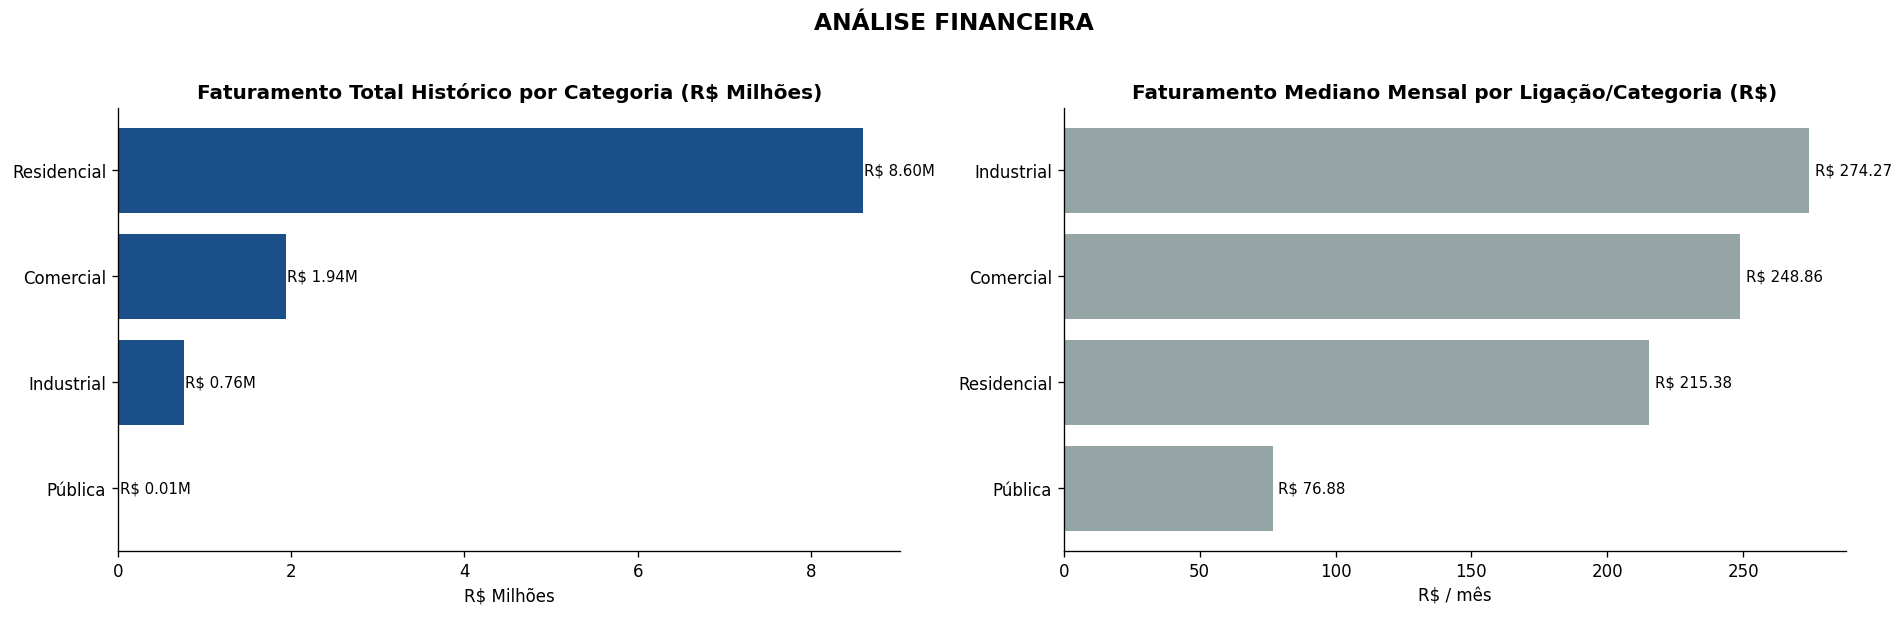

✅ Gráfico 06 salvo


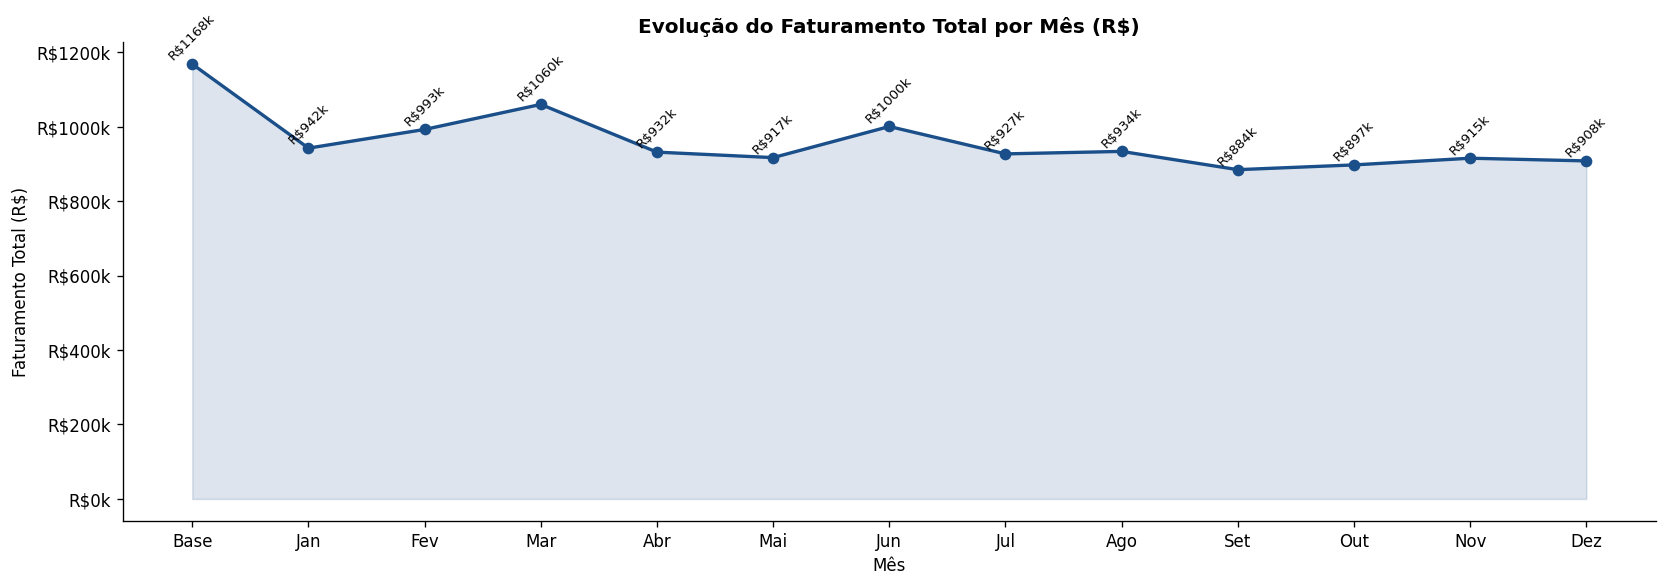

✅ Gráfico 07 salvo


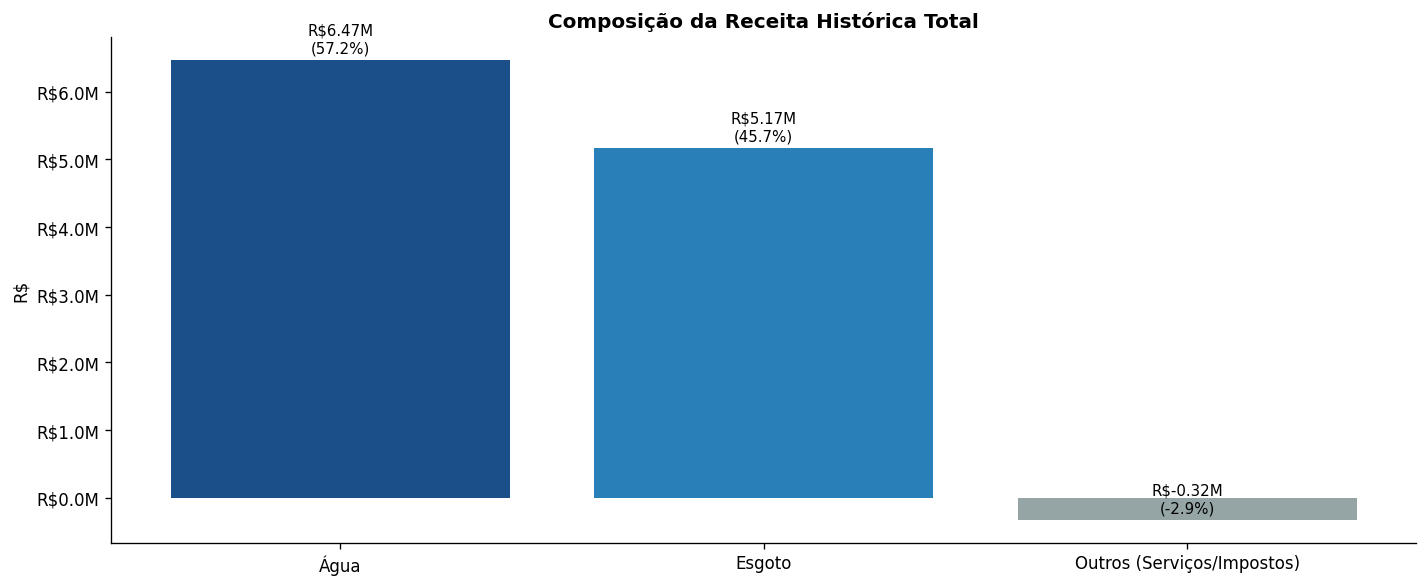

✅ Gráfico 08 salvo

=== TOP 10 LIGAÇÕES POR FATURAMENTO HISTÓRICO ===

   MATRICULA CATEGORIA_PRINCIPAL  TOTAL_FATURADO_HISTORICO  MEDIA_CONSUMO_HISTORICO  NUMERO_ECONOMIAS_RES  NUMERO_ECONOMIAS_COM  NUMERO_ECONOMIAS_IND  SCORE_RISCO
0  1373623-0         Residencial                 441051.01              3146.250000                 193.0                   8.0                   NaN            1
1  1373826-7           Comercial                 339228.48               289.500000                   NaN                 213.0                   NaN            0
2  1373698-1           Comercial                 326487.51              1112.416667                   NaN                 205.0                   NaN            0
3  1373895-0         Residencial                 190301.86              1509.166667                 116.0                  14.0                   NaN            0
4  1374136-5           Comercial                 184620.95               960.750000                   NaN         

In [17]:
# ============================================================
# BLOCO 3 — ANÁLISE FINANCEIRA
# ============================================================

# --- 3.1 Faturamento total histórico por categoria ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fat_cat = df_at.groupby('CATEGORIA_PRINCIPAL')['TOTAL_FATURADO_HISTORICO'].sum().sort_values()
axes[0].barh(fat_cat.index, fat_cat.values / 1e6, color=COR_PRINCIPAL)
axes[0].set_title('Faturamento Total Histórico por Categoria (R$ Milhões)', fontweight='bold')
axes[0].set_xlabel('R$ Milhões')
for i, v in enumerate(fat_cat.values):
    axes[0].text(v/1e6 + 0.01, i, f'R$ {v/1e6:.2f}M', va='center', fontsize=9)

# Faturamento médio por ligação por categoria
fat_medio_cat = df_at.groupby('CATEGORIA_PRINCIPAL')['MEDIA_FATURADO_HISTORICO'].median().sort_values()
axes[1].barh(fat_medio_cat.index, fat_medio_cat.values, color=COR_NEUTRO)
axes[1].set_title('Faturamento Mediano Mensal por Ligação/Categoria (R$)', fontweight='bold')
axes[1].set_xlabel('R$ / mês')
for i, v in enumerate(fat_medio_cat.values):
    axes[1].text(v + 2, i, f'R$ {v:.2f}', va='center', fontsize=9)

plt.suptitle('ANÁLISE FINANCEIRA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(output_path + '06_faturamento_por_categoria.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Gráfico 06 salvo")

# --- 3.2 Evolução do faturamento total ao longo dos meses ---
fig, ax = plt.subplots(figsize=(14, 5))

fat_mensal = df_at[valor_total_cols].sum()
ax.plot(meses_label, fat_mensal.values, marker='o',
        color=COR_PRINCIPAL, linewidth=2, markersize=6)
ax.fill_between(meses_label, fat_mensal.values, alpha=0.15, color=COR_PRINCIPAL)

for i, v in enumerate(fat_mensal.values):
    ax.text(i, v + fat_mensal.max()*0.01, f'R${v/1e3:.0f}k',
            ha='center', fontsize=8, rotation=45)

ax.set_title('Evolução do Faturamento Total por Mês (R$)', fontweight='bold')
ax.set_ylabel('Faturamento Total (R$)')
ax.set_xlabel('Mês')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e3:.0f}k'))
plt.tight_layout()
plt.savefig(output_path + '07_evolucao_faturamento_mensal.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Gráfico 07 salvo")

# --- 3.3 Composição receita água vs esgoto ---
fig, ax = plt.subplots(figsize=(12, 5))

agua_total   = df_at['TOTAL_AGUA_HISTORICO'].sum()
esgoto_total = df_at['TOTAL_ESGOTO_HISTORICO'].sum()
outros_total = df_at['TOTAL_FATURADO_HISTORICO'].sum() - agua_total - esgoto_total

categorias_rec = ['Água', 'Esgoto', 'Outros (Serviços/Impostos)']
valores_rec    = [agua_total, esgoto_total, outros_total]
cores_rec      = [COR_PRINCIPAL, '#2980B9', COR_NEUTRO]

bars = ax.bar(categorias_rec, valores_rec, color=cores_rec)
ax.set_title('Composição da Receita Histórica Total', fontweight='bold')
ax.set_ylabel('R$')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
for bar, v in zip(bars, valores_rec):
    pct = v / sum(valores_rec) * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + sum(valores_rec)*0.01,
            f'R${v/1e6:.2f}M\n({pct:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(output_path + '08_composicao_receita.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Gráfico 08 salvo")

# --- 3.4 Top 10 ligações por faturamento total histórico ---
top10_fat = df_at.nlargest(10, 'TOTAL_FATURADO_HISTORICO')[
    ['MATRICULA','CATEGORIA_PRINCIPAL','TOTAL_FATURADO_HISTORICO',
     'MEDIA_CONSUMO_HISTORICO','NUMERO_ECONOMIAS_RES',
     'NUMERO_ECONOMIAS_COM','NUMERO_ECONOMIAS_IND','SCORE_RISCO']
].reset_index(drop=True)

print("\n=== TOP 10 LIGAÇÕES POR FATURAMENTO HISTÓRICO ===\n")
print(top10_fat.to_string())

# --- 3.5 Resumo financeiro ---
print(f"\n=== RESUMO FINANCEIRO ===\n")
print(f"Receita total histórica:             R$ {df_at['TOTAL_FATURADO_HISTORICO'].sum():>15,.2f}")
print(f"  └─ Água:                           R$ {agua_total:>15,.2f} ({agua_total/df_at['TOTAL_FATURADO_HISTORICO'].sum()*100:.1f}%)")
print(f"  └─ Esgoto:                         R$ {esgoto_total:>15,.2f} ({esgoto_total/df_at['TOTAL_FATURADO_HISTORICO'].sum()*100:.1f}%)")
print(f"  └─ Outros:                         R$ {outros_total:>15,.2f} ({outros_total/df_at['TOTAL_FATURADO_HISTORICO'].sum()*100:.1f}%)")
print(f"\nFaturamento médio mensal da carteira:R$ {fat_mensal.mean():>15,.2f}")
print(f"Faturamento máximo em um mês:        R$ {fat_mensal.max():>15,.2f}")
print(f"Faturamento mínimo em um mês:        R$ {fat_mensal.min():>15,.2f}")

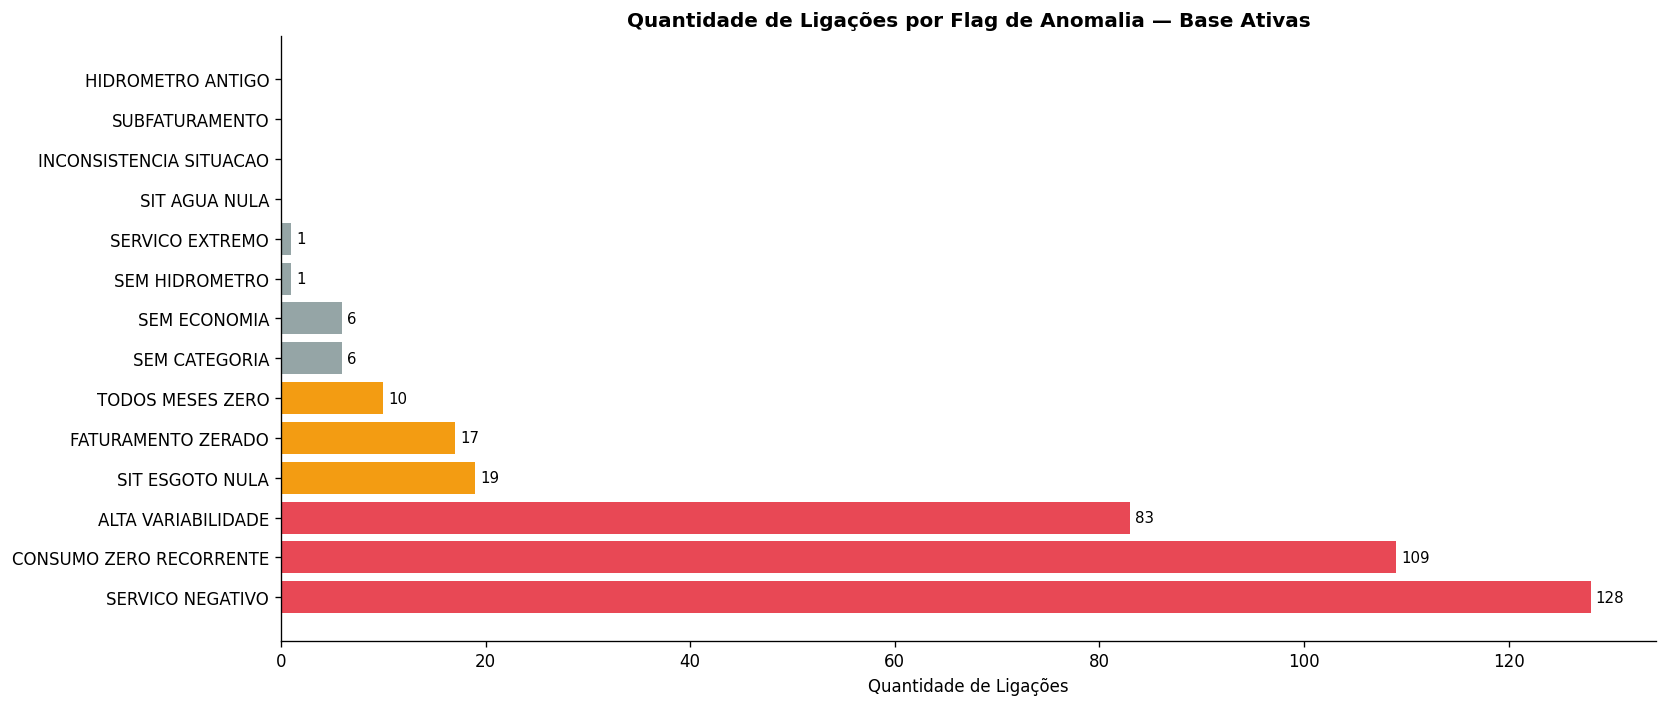

✅ Gráfico 09 salvo


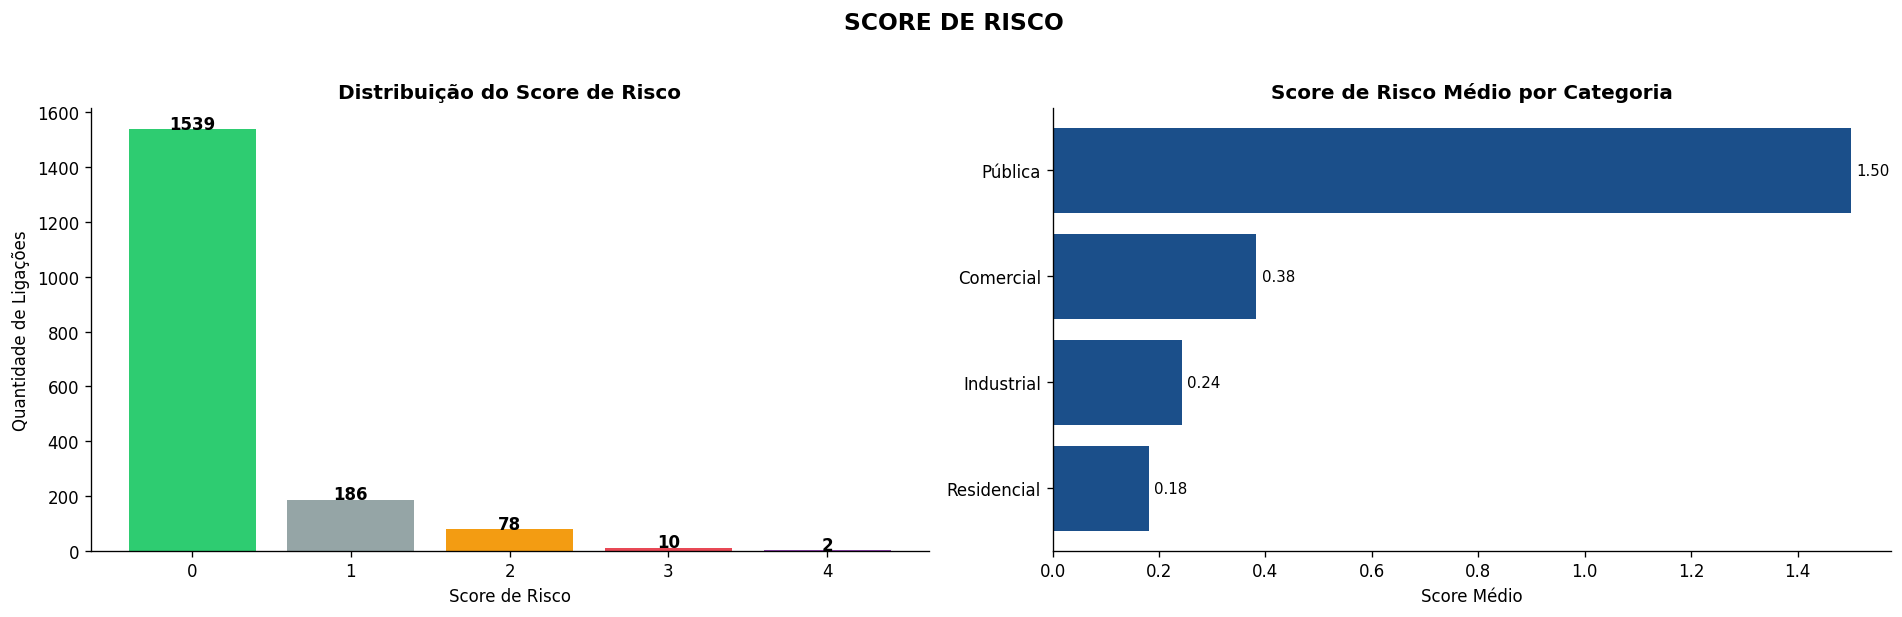

✅ Gráfico 10 salvo

=== LIGAÇÕES DE ALTO RISCO (SCORE >= 3) ===

    MATRICULA CATEGORIA_PRINCIPAL  SCORE_RISCO  MEDIA_CONSUMO_HISTORICO  TOTAL_FATURADO_HISTORICO  MESES_CONSUMO_ZERO  FLAG_CONSUMO_ZERO_RECORRENTE  FLAG_SERVICO_NEGATIVO  FLAG_INCONSISTENCIA_SITUACAO  FLAG_ALTA_VARIABILIDADE
0   1374108-0           Comercial            4                 0.000000                      0.00                  12                             1                      1                             0                        0
1   1374107-1           Comercial            4                 0.000000                      0.00                  12                             1                      1                             0                        0
2   1219707-6           Comercial            3                 8.916667                      0.00                   2                             0                      1                             0                        1
3   1371190-3         Residenci

In [19]:
# ============================================================
# BLOCO 4 — ANOMALIAS E DETECÇÃO DE PROBLEMAS
# ============================================================

# Limpando espaços em branco nos nomes das colunas por segurança
df_at.columns = df_at.columns.str.strip()

flag_cols = [c for c in df_at.columns if c.startswith('FLAG_')]

# --- 4.1 Visão geral das flags ---
fig, ax = plt.subplots(figsize=(14, 6))

flag_counts = {f: df_at[f].sum() for f in flag_cols}
flag_counts = dict(sorted(flag_counts.items(), key=lambda x: x[1], reverse=True))
flag_labels = [f.replace('FLAG_', '').replace('_', ' ') for f in flag_counts.keys()]
cores_flags = [COR_ALERTA if v >= 50 else '#F39C12' if v >= 10 else COR_NEUTRO
               for v in flag_counts.values()]

bars = ax.barh(flag_labels, list(flag_counts.values()), color=cores_flags)
ax.set_title('Quantidade de Ligações por Flag de Anomalia — Base Ativas',
             fontweight='bold')
ax.set_xlabel('Quantidade de Ligações')
for bar, v in zip(bars, flag_counts.values()):
    if v > 0:
        ax.text(v + 0.5, bar.get_y() + bar.get_height()/2,
                str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(output_path + '09_visao_flags_anomalias.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Gráfico 09 salvo")

# --- 4.2 Distribuição do score de risco ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

score_dist = df_at['SCORE_RISCO'].value_counts().sort_index()
cores_score = [COR_OK, COR_NEUTRO, '#F39C12', COR_ALERTA, '#8E44AD']
axes[0].bar(score_dist.index.astype(str), score_dist.values,
            color=cores_score[:len(score_dist)])
axes[0].set_title('Distribuição do Score de Risco', fontweight='bold')
axes[0].set_xlabel('Score de Risco')
axes[0].set_ylabel('Quantidade de Ligações')
for i, v in enumerate(score_dist.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=10, fontweight='bold')

score_cat = df_at.groupby('CATEGORIA_PRINCIPAL')['SCORE_RISCO'].mean().sort_values()
axes[1].barh(score_cat.index, score_cat.values, color=COR_PRINCIPAL)
axes[1].set_title('Score de Risco Médio por Categoria', fontweight='bold')
axes[1].set_xlabel('Score Médio')
for i, v in enumerate(score_cat.values):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)

plt.suptitle('SCORE DE RISCO', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(output_path + '10_score_risco.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Gráfico 10 salvo")


# --- 4.3 Ligações de alto risco ---
alto_risco = df_at[df_at['SCORE_RISCO'] >= 3].sort_values(
    'SCORE_RISCO', ascending=False
)[['MATRICULA','CATEGORIA_PRINCIPAL','SCORE_RISCO',
   'MEDIA_CONSUMO_HISTORICO','TOTAL_FATURADO_HISTORICO',
   'MESES_CONSUMO_ZERO','FLAG_CONSUMO_ZERO_RECORRENTE',
   'FLAG_SERVICO_NEGATIVO','FLAG_INCONSISTENCIA_SITUACAO',
   'FLAG_ALTA_VARIABILIDADE']].reset_index(drop=True)

print(f"\n=== LIGAÇÕES DE ALTO RISCO (SCORE >= 3) ===\n")
print(alto_risco.to_string())

# --- 4.4 Impacto financeiro das anomalias ---
print(f"\n=== IMPACTO FINANCEIRO DAS ANOMALIAS ===\n")

# Faturamento zerado
mask_fat_zero = (
    (df_at['VALOR_TOTAL'] == 0) &
    (df_at['VOLUME_FATURADO'] > 0)
)
rec_fat_zero = (df_at[mask_fat_zero]['VALOR_AGUA'] +
                df_at[mask_fat_zero]['VALOR_ESGOTO']).sum()
print(f"1. Faturamento zerado (mês base):")
print(f"   Ligações:              {mask_fat_zero.sum()}")
print(f"   Potencial de receita:  R$ {rec_fat_zero:,.2f}")
print(f"   Projeção anual:        R$ {rec_fat_zero * 12:,.2f}")

# Consumo zero recorrente
mask_zero_rec = df_at['FLAG_CONSUMO_ZERO_RECORRENTE'] == 1
media_minimo = df_at[mask_zero_rec]['MEDIA_FATURADO_HISTORICO'].mean()
print(f"\n2. Consumo zero recorrente (> 3 meses zerados):")
print(f"   Ligações:              {mask_zero_rec.sum()}")
print(f"   Faturamento médio:     R$ {media_minimo:,.2f}/mês (apenas mínimo tarifário)")

# Alta variabilidade
mask_var = df_at['FLAG_ALTA_VARIABILIDADE'] == 1
consumo_medio_var = df_at[mask_var]['MEDIA_CONSUMO_HISTORICO'].mean()
consumo_medio_geral = df_at['MEDIA_CONSUMO_HISTORICO'].mean()
print(f"\n3. Alta variabilidade de consumo (CV > 1.5):")
print(f"   Ligações:              {mask_var.sum()}")
print(f"   Consumo médio grupo:   {consumo_medio_var:.1f} m³/mês")
print(f"   Consumo médio geral:   {consumo_medio_geral:.1f} m³/mês")

# Inconsistência situação
mask_inc = df_at['FLAG_INCONSISTENCIA_SITUACAO'] == 1
print(f"\n4. Inconsistência cadastral água x esgoto:")
print(f"   Ligações:              {mask_inc.sum()}")

# Leitura de ocorrência (COMENTADO PARA EVITAR KEYERROR)
# mask_oc = df_at['FLAG_LEITURA_OCORRENCIA'] == 1
# print(f"\n5. Leituras com código de ocorrência:")
# print(f"   Ligações:              {mask_oc.sum()}")

# Todos os meses zerados
mask_zero_total = df_at['MESES_CONSUMO_ZERO'] == 12
print(f"\n6. Ligações ativas com todos os 12 meses zerados:")
print(f"   Ligações:              {mask_zero_total.sum()}")
print(df_at[mask_zero_total][['MATRICULA','CATEGORIA_PRINCIPAL',
    'VOLUME_FATURADO','VALOR_TOTAL','TOTAL_FATURADO_HISTORICO']].to_string())

In [20]:
# Checar quais flags existem no df_at
flags_at = [c for c in df_at.columns if c.startswith('FLAG_')]
print(f"Total de flags no df_at: {len(flags_at)}")
for f in flags_at:
    print(f"  {f}: {df_at[f].sum()}")

Total de flags no df_at: 14
  FLAG_SIT_AGUA_NULA: 0
  FLAG_SIT_ESGOTO_NULA: 19
  FLAG_SEM_CATEGORIA: 6
  FLAG_SEM_HIDROMETRO: 1
  FLAG_SEM_ECONOMIA: 6
  FLAG_INCONSISTENCIA_SITUACAO: 0
  FLAG_SERVICO_NEGATIVO: 128
  FLAG_FATURAMENTO_ZERADO: 17
  FLAG_SERVICO_EXTREMO: 1
  FLAG_TODOS_MESES_ZERO: 10
  FLAG_SUBFATURAMENTO: 0
  FLAG_HIDROMETRO_ANTIGO: 0
  FLAG_CONSUMO_ZERO_RECORRENTE: 109
  FLAG_ALTA_VARIABILIDADE: 83
